# F1_Definicion

## Título del proyecto
Optimización del OEE mediante Mantenimiento Predictivo Inteligente en Activos Críticos Industriales

## Problemática
Las fallas no programadas en activos industriales críticos afectan la disponibilidad operacional y deterioran el indicador OEE. En este contexto, el proyecto busca establecer una base reproducible para analizar un conjunto de datos de mantenimiento predictivo y preparar, en fases posteriores, el estudio de variables operacionales asociadas a eventos de falla.

## Dataset utilizado
El proyecto utiliza un dataset histórico de mantenimiento predictivo compuesto por 124494 registros y 12 columnas. El conjunto incluye una dimensión temporal (date), un identificador de activo (device), una variable objetivo binaria (failure) y nueve métricas operacionales (metric1 a metric9).

## Objetivo general
Diseñar, estructurar e implementar un flujo analítico reproducible y robusto, basado en programación científica en Python, para anticipar eventos de falla en activos industriales críticos, contribuyendo a la mejora de la disponibilidad operacional y a la optimización del indicador OEE.

## Objetivos específicos
- Configurar un entorno de desarrollo reproducible mediante el uso de control de versiones (Git/GitHub) y la gestión de dependencias a través de entornos virtuales (.venv) y archivos de requerimientos.
- Implementar la carga estructurada del dataset histórico de mantenimiento predictivo utilizado en el proyecto herramientas del ecosistema Python, asegurando la integridad, consistencia y trazabilidad de los datos originales.
- Preparar las bases para el análisis exploratorio de datos (EDA), incluyendo la revisión inicial de variables y la identificación preliminar del desbalance de clases.
- Proyectar el diseño de un flujo de preprocesamiento de datos que incorpore limpieza estructural, tratamiento de variables continuas y codificación de variables categóricas en fases posteriores.
- Proyectar la evaluación de modelos de clasificación supervisada mediante métricas adaptadas a contextos desbalanceados, tales como F1-Score, Recall y Precision-Recall AUC, en fases posteriores del proyecto.

## Alcance de este notebook
Este notebook corresponde a la Fase 1 del proyecto y se enfoca en la definición del problema, la organización del entorno reproducible, la carga inicial del dataset y la documentación técnica base. Las etapas de análisis exploratorio, preprocesamiento, modelación y evaluación serán abordadas en fases posteriores.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

def cargar_datos():
    possible_paths = [
        Path("data/raw/predictive_maintenance_dataset.csv"),
        Path("../data/raw/predictive_maintenance_dataset.csv")
    ]
    
    for path in possible_paths:
        if path.exists():
            df = pd.read_csv(path)
            return df, path
    
    raise FileNotFoundError("No se encontró el archivo predictive_maintenance_dataset.csv")


def resumir_estructura(df):
    print("Columnas del dataset:")
    print(df.columns)

    print("\nPrimeras 5 filas:")
    display(df.head())

    print("\nTipos de datos:")
    print(df.dtypes)

    print("\nDimensiones del dataset:")
    print(df.shape)


def analizar_variable_objetivo(df):
    conteo = df["failure"].value_counts()
    proporcion = df["failure"].value_counts(normalize=True)

    print("Distribución de la variable objetivo:")
    print(conteo)

    print("\nDistribución relativa:")
    print(np.round(proporcion, 6))

    return conteo, proporcion


def revisar_calidad(df):
    print("Valores nulos por columna:")
    print(df.isnull().sum())

    print("\nCantidad de filas duplicadas:")
    print(df.duplicated().sum())


def resumen_estadistico(df):
    print("Resumen estructural del dataset:")
    df.info()

    print("\nResumen estadístico de variables numéricas:")
    display(df.describe())


def analizar_fallas_por_fecha(df):
    df_temp = df.copy()
    df_temp["date"] = pd.to_datetime(df_temp["date"], dayfirst=True)

    fallas_por_fecha = df_temp.groupby("date")["failure"].sum()

    print("Primeros registros agregados por fecha:")
    display(fallas_por_fecha.head())

    ax = fallas_por_fecha.plot(
        figsize=(10, 4),
        title="Fallas registradas por fecha"
    )
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Cantidad de fallas")

    return fallas_por_fecha

In [2]:
df, dataset_path = cargar_datos()

print("Archivo cargado desde:", dataset_path)
print("Dimensiones del dataset:", df.shape)

resumir_estructura(df)

Archivo cargado desde: ..\data\raw\predictive_maintenance_dataset.csv
Dimensiones del dataset: (124494, 12)
Columnas del dataset:
Index(['date', 'device', 'failure', 'metric1', 'metric2', 'metric3', 'metric4',
       'metric5', 'metric6', 'metric7', 'metric8', 'metric9'],
      dtype='str')

Primeras 5 filas:


,date,device,failure,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9
0,01/01/2015,S1F01085,0,215630672,55,0,52,6,407438,0,0,7
1,01/01/2015,S1F0166B,0,61370680,0,3,0,6,403174,0,0,0
2,01/01/2015,S1F01E6Y,0,173295968,0,0,0,12,237394,0,0,0
3,01/01/2015,S1F01JE0,0,79694024,0,0,0,6,410186,0,0,0
4,01/01/2015,S1F01R2B,0,135970480,0,0,0,15,313173,0,0,3



Tipos de datos:
date         str
device       str
failure    int64
metric1    int64
metric2    int64
metric3    int64
metric4    int64
metric5    int64
metric6    int64
metric7    int64
metric8    int64
metric9    int64
dtype: object

Dimensiones del dataset:
(124494, 12)


In [3]:
conteo_failure, proporcion_failure = analizar_variable_objetivo(df)

Distribución de la variable objetivo:
failure
0    124388
1       106
Name: count, dtype: int64

Distribución relativa:
failure
0    0.999149
1    0.000851
Name: proportion, dtype: float64


## Hallazgos técnicos iniciales
A partir de la revisión estructural del dataset, se identifica que la variable `failure` será utilizada como variable objetivo preliminar del proyecto, ya que representa la ocurrencia general de eventos de falla.

Asimismo, se observa que el conjunto de datos presenta un desbalance de clases significativo: la gran mayoría de los registros corresponde a condiciones normales de operación (`failure = 0`), mientras que los casos de falla (`failure = 1`) representan una proporción muy menor del total.

Este hallazgo será relevante en fases posteriores del proyecto, especialmente en el análisis exploratorio, el preprocesamiento y la selección de métricas de evaluación para modelos de clasificación.

In [4]:
revisar_calidad(df)

Valores nulos por columna:
date       0
device     0
failure    0
metric1    0
metric2    0
metric3    0
metric4    0
metric5    0
metric6    0
metric7    0
metric8    0
metric9    0
dtype: int64

Cantidad de filas duplicadas:
1


## Revisión inicial de calidad de datos
A partir de la revisión básica del dataset, no se identifican valores nulos en las columnas analizadas, lo que sugiere una adecuada completitud de la información en esta fase inicial.

No obstante, se detecta la existencia de 1 fila duplicada en el conjunto de datos. Este hallazgo será considerado en etapas posteriores de preprocesamiento, donde se evaluará su tratamiento dentro del flujo analítico reproducible del proyecto.

## Resumen estructural del dataset
La revisión estructural inicial indica que el conjunto de datos contiene 124494 registros y 12 columnas, con una combinación de variables temporales, de identificación y numéricas. En particular, se observan 2 columnas de tipo texto (`date` y `device`) y 10 columnas numéricas, incluyendo la variable objetivo preliminar `failure`.

Asimismo, el resultado de `df.info()` confirma que todas las columnas presentan el mismo número de valores no nulos, lo que refuerza la consistencia estructural del dataset en esta fase inicial. El tamaño aproximado en memoria es de 11.4 MB, por lo que el conjunto puede ser manipulado de forma adecuada dentro del entorno reproducible configurado para el proyecto.

In [5]:
resumen_estadistico(df)

Resumen estructural del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 124494 entries, 0 to 124493
Data columns (total 12 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   date     124494 non-null  str  
 1   device   124494 non-null  str  
 2   failure  124494 non-null  int64
 3   metric1  124494 non-null  int64
 4   metric2  124494 non-null  int64
 5   metric3  124494 non-null  int64
 6   metric4  124494 non-null  int64
 7   metric5  124494 non-null  int64
 8   metric6  124494 non-null  int64
 9   metric7  124494 non-null  int64
 10  metric8  124494 non-null  int64
 11  metric9  124494 non-null  int64
dtypes: int64(10), str(2)
memory usage: 11.4 MB

Resumen estadístico de variables numéricas:


,failure,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9
count,124494.000000,1.244940e+05,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000
mean,0.000851,1.223881e+08,159.492706,9.940897,1.741120,14.222669,260172.657726,0.292528,0.292528,13.013848
std,0.029167,7.045933e+07,2179.677781,185.748131,22.908507,15.943028,99151.078547,7.436924,7.436924,275.661220
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,1.000000,8.000000,0.000000,0.000000,0.000000
25%,0.000000,6.128476e+07,0.000000,0.000000,0.000000,8.000000,221452.000000,0.000000,0.000000,0.000000
50%,0.000000,1.227974e+08,0.000000,0.000000,0.000000,10.000000,249799.500000,0.000000,0.000000,0.000000
75%,0.000000,1.833096e+08,0.000000,0.000000,0.000000,12.000000,310266.000000,0.000000,0.000000,0.000000
max,1.000000,2.441405e+08,64968.000000,24929.000000,1666.000000,98.000000,689161.000000,832.000000,832.000000,70000.000000


In [11]:
def analizar_fallas_por_fecha(df):
    df_temp = df.copy()
    df_temp["date"] = pd.to_datetime(df_temp["date"], format="mixed", dayfirst=True)

    fallas_por_fecha = df_temp.groupby("date")["failure"].sum()

    print("Primeros registros agregados por fecha:")
    display(fallas_por_fecha.head())

    ax = fallas_por_fecha.plot(
        figsize=(10, 4),
        title="Fallas registradas por fecha"
    )
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Cantidad de fallas")

    return fallas_por_fecha

Primeros registros agregados por fecha:


date
2015-01-01    0
2015-01-02    0
2015-01-03    0
2015-01-04    0
2015-01-05    0
Name: failure, dtype: int64

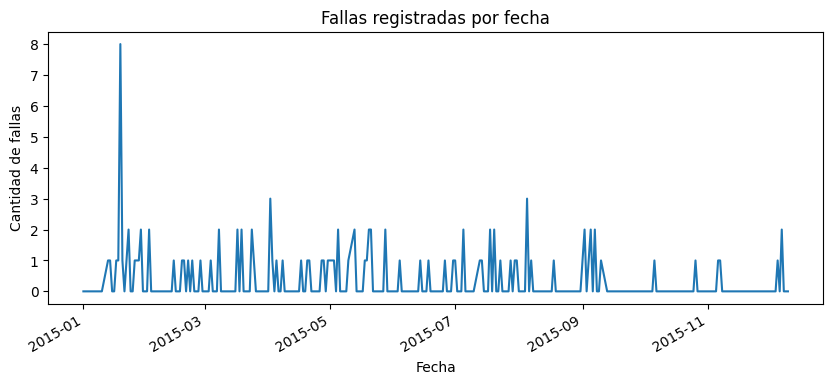

In [12]:
fallas_por_fecha = analizar_fallas_por_fecha(df)

## Conclusiones del Análisis Exploratorio

- El dataset contiene 124.494 registros y 12 variables.
- No se encontraron valores nulos...
- La variable objetivo failure presenta un fuerte desbalance de clases.
- Se detectó 1 fila duplicada en la revisión inicial de calidad.
- La dimensión temporal (date) permite observar la distribución de eventos de falla a lo largo del período analizado.